# EDA Data Citra Dinsos Jatim

Notebook ini digunakan untuk melakukan Exploratory Data Analysis (EDA) pada Data Citra dan feature jenis atap, dinding, dan lantai terhadap data keluarga Dinsos Jatim.

## Import Library

In [1]:
from collections import Counter
from pathlib import Path
import re
import math

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from openpyxl import load_workbook

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

DATA_PATH = Path("../data/data_keluarga_dinsos_jatim.xlsx")
SHEET_NAME = None  # None = sheet aktif pertama
USE_ROWS_SAMPLE_FOR_PREVIEW = 20

## Definisi kategori valid

In [2]:
VALID_LANTAI = {
    "1": "Marmer/granit",
    "2": "Keramik",
    "3": "Parket/vinil/karpet",
    "4": "Ubin/tegel/teraso",
    "5": "Kayu/papan",
    "6": "Semen/bata merah",
    "7": "Bambu",
    "8": "Tanah",
    "9": "Lainnya",
}

VALID_DINDING = {
    "1": "Tembok",
    "2": "Plesteran anyaman bambu/kawat",
    "3": "Kayu/papan/gypsum/GRC/calciboard",
    "4": "Anyaman bambu",
    "5": "Batang kayu",
    "6": "Bambu",
    "7": "Lainnya",
}

VALID_ATAP = {
    "1": "Beton",
    "2": "Genteng",
    "3": "Seng",
    "4": "Asbes",
    "5": "Bambu",
    "6": "Kayu/sirap",
    "7": "Jerami/ijuk/daun-daunan/rumbia",
    "8": "Lainnya",
}

TARGET_COLS = [
    "id_lantai_terluas",
    "id_dinding_terluas",
    "id_atap_terluas",
    "foto_rumah",
    "foto_rumah_tampak_dalam",
]

## Fungsi bantu untuk normalisasi dan klasifikasi

In [3]:
def normalize_code(value):
    if value is None:
        return None

    if isinstance(value, float):
        if math.isnan(value):
            return None
        if value.is_integer():
            return str(int(value))
        return str(value).strip()

    if isinstance(value, int):
        return str(value)

    s = str(value).strip()
    if s == "":
        return None

    if re.fullmatch(r"\d+\.0", s):
        return str(int(float(s)))

    return s

In [4]:
def extract_minio_url(value):
    if value is None:
        return None

    s = str(value).strip()
    if s == "" or s == "[]":
        return None

    if s.startswith("[") and s.endswith("]"):
        s = s[1:-1].strip()

    if s == "":
        return None

    if s.endswith("prefix="):
        return None

    return s

In [5]:
def classify_image_schema(exterior_url, interior_url):
    has_exterior = exterior_url is not None
    has_interior = interior_url is not None

    if has_exterior and has_interior:
        return "multi_images"
    if has_interior and not has_exterior:
        return "single_image_interior_only"
    if has_exterior and not has_interior:
        return "single_image_exterior_only"
    return "no_images"

In [6]:
def expected_mapping_for_column(col_name):
    if col_name == "id_lantai_terluas":
        return VALID_LANTAI
    if col_name == "id_dinding_terluas":
        return VALID_DINDING
    if col_name == "id_atap_terluas":
        return VALID_ATAP
    raise KeyError(col_name)

## Membaca Excel secara streaming

In [7]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {DATA_PATH.resolve()}")

wb = load_workbook(DATA_PATH, read_only=True, data_only=True)
ws = wb[SHEET_NAME] if SHEET_NAME else wb[wb.sheetnames[0]]

headers = next(ws.iter_rows(min_row=1, max_row=1, values_only=True))
header_map = {str(h).strip(): idx for idx, h in enumerate(headers) if h is not None}

missing_cols = [c for c in TARGET_COLS if c not in header_map]
if missing_cols:
    raise ValueError(f"Kolom berikut tidak ditemukan di Excel: {missing_cols}")

print("Sheet aktif:", ws.title)
print("Jumlah kolom total:", len(headers))
print("Kolom target ditemukan:", TARGET_COLS)

Sheet aktif: keluarga_kab_kota_malang_050520
Jumlah kolom total: 54
Kolom target ditemukan: ['id_lantai_terluas', 'id_dinding_terluas', 'id_atap_terluas', 'foto_rumah', 'foto_rumah_tampak_dalam']


## EDA 

In [8]:
total_rows = 0
rows_with_any_image = 0
schema_counter = Counter()

counts_valid = {
    "id_lantai_terluas": Counter(),
    "id_dinding_terluas": Counter(),
    "id_atap_terluas": Counter(),
}

counts_anomaly = {
    "id_lantai_terluas": Counter(),
    "id_dinding_terluas": Counter(),
    "id_atap_terluas": Counter(),
}

sample_anomalies = {
    "id_lantai_terluas": [],
    "id_dinding_terluas": [],
    "id_atap_terluas": [],
}

sample_image_rows = []

for row_idx, row in enumerate(ws.iter_rows(min_row=2, values_only=True), start=2):
    total_rows += 1

    lantai_raw = row[header_map["id_lantai_terluas"]]
    dinding_raw = row[header_map["id_dinding_terluas"]]
    atap_raw = row[header_map["id_atap_terluas"]]
    exterior_raw = row[header_map["foto_rumah"]]
    interior_raw = row[header_map["foto_rumah_tampak_dalam"]]

    exterior_url = extract_minio_url(exterior_raw)
    interior_url = extract_minio_url(interior_raw)

    schema = classify_image_schema(exterior_url, interior_url)
    schema_counter[schema] += 1

    if schema == "no_images":
        continue

    rows_with_any_image += 1

    if len(sample_image_rows) < USE_ROWS_SAMPLE_FOR_PREVIEW:
        sample_image_rows.append({
            "row_idx": row_idx,
            "id_lantai_terluas": lantai_raw,
            "id_dinding_terluas": dinding_raw,
            "id_atap_terluas": atap_raw,
            "foto_rumah": exterior_url,
            "foto_rumah_tampak_dalam": interior_url,
            "image_schema": schema,
        })

    # EDA untuk fitur kategorikal hanya pada baris yang punya image
    for col_name, raw_value in [
        ("id_lantai_terluas", lantai_raw),
        ("id_dinding_terluas", dinding_raw),
        ("id_atap_terluas", atap_raw),
    ]:
        normalized = normalize_code(raw_value)
        mapping = expected_mapping_for_column(col_name)

        if normalized is None:
            counts_anomaly[col_name]["missing"] += 1
            if len(sample_anomalies[col_name]) < USE_ROWS_SAMPLE_FOR_PREVIEW:
                sample_anomalies[col_name].append({
                    "row_idx": row_idx,
                    "value": raw_value,
                    "reason": "missing",
                    "schema": schema,
                })
        elif normalized in mapping:
            counts_valid[col_name][normalized] += 1
        else:
            counts_anomaly[col_name][normalized] += 1
            if len(sample_anomalies[col_name]) < USE_ROWS_SAMPLE_FOR_PREVIEW:
                sample_anomalies[col_name].append({
                    "row_idx": row_idx,
                    "value": raw_value,
                    "reason": "out_of_scope",
                    "schema": schema,
                })

print("Selesai memproses baris:", total_rows)
print("Baris dengan minimal satu image:", rows_with_any_image)
print("Distribusi skema image:", schema_counter)

Selesai memproses baris: 1048575
Baris dengan minimal satu image: 61587
Distribusi skema image: Counter({'no_images': 986988, 'multi_images': 48000, 'single_image_exterior_only': 13587})


### Ringkasan gambar

In [9]:
image_summary = pd.DataFrame(
    [
        {"skema": k, "jumlah": v, "persentase_dari_semua_baris": (v / total_rows * 100 if total_rows else 0)}
        for k, v in schema_counter.items()
    ]
).sort_values("jumlah", ascending=False)

image_summary

,skema,jumlah,persentase_dari_semua_baris
0,no_images,986988,94.126600
2,multi_images,48000,4.577641
1,single_image_exterior_only,13587,1.295759


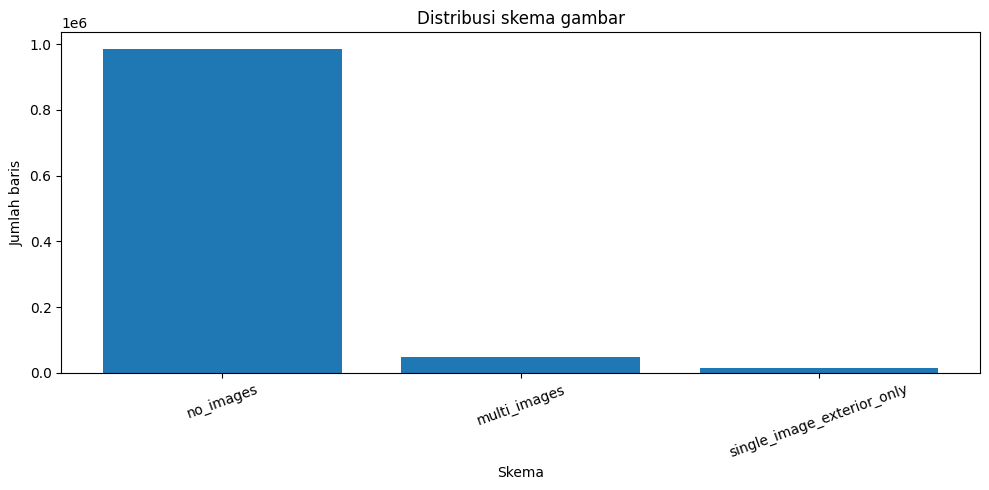

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(image_summary["skema"], image_summary["jumlah"])
ax.set_title("Distribusi skema gambar")
ax.set_xlabel("Skema")
ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Persebaran jenis lantai

In [11]:
lantai_df = pd.DataFrame(
    [
        {
            "kode": code,
            "kategori": VALID_LANTAI[code],
            "jumlah": counts_valid["id_lantai_terluas"].get(code, 0),
        }
        for code in VALID_LANTAI
    ]
)
lantai_df["persentase_dari_semua_baris"] = lantai_df["jumlah"] / total_rows * 100 if total_rows else 0
lantai_df["persentase_dari_baris_berimage"] = lantai_df["jumlah"] / rows_with_any_image * 100 if rows_with_any_image else 0
lantai_df.sort_values("jumlah", ascending=False)

,kode,kategori,jumlah,persentase_dari_semua_baris,persentase_dari_baris_berimage
1,2,Keramik,31575,3.011230,51.268937
5,6,Semen/bata merah,14438,1.376916,23.443259
3,4,Ubin/tegel/teraso,7413,0.706959,12.036631
7,8,Tanah,3087,0.294400,5.012421
0,1,Marmer/granit,338,0.032234,0.548817
2,3,Parket/vinil/karpet,154,0.014687,0.250053
8,9,Lainnya,116,0.011063,0.188351
4,5,Kayu/papan,76,0.007248,0.123403
6,7,Bambu,24,0.002289,0.038969


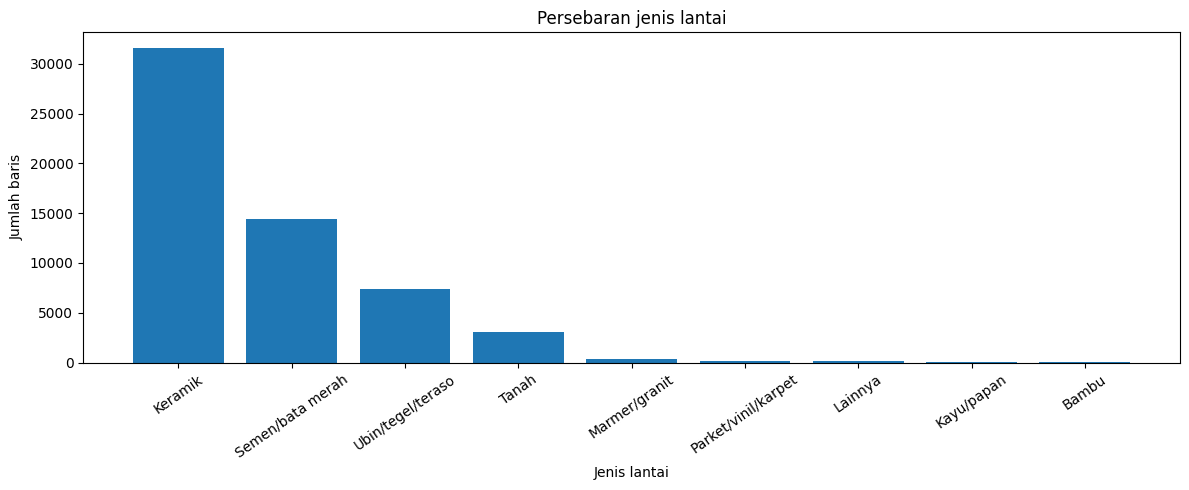

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
temp = lantai_df.sort_values("jumlah", ascending=False)
ax.bar(temp["kategori"], temp["jumlah"])
ax.set_title("Persebaran jenis lantai")
ax.set_xlabel("Jenis lantai")
ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

### Persebaran jenis dinding

In [13]:
dinding_df = pd.DataFrame(
    [
        {
            "kode": code,
            "kategori": VALID_DINDING[code],
            "jumlah": counts_valid["id_dinding_terluas"].get(code, 0),
        }
        for code in VALID_DINDING
    ]
)
dinding_df["persentase_dari_semua_baris"] = dinding_df["jumlah"] / total_rows * 100 if total_rows else 0
dinding_df["persentase_dari_baris_berimage"] = dinding_df["jumlah"] / rows_with_any_image * 100 if rows_with_any_image else 0
dinding_df.sort_values("jumlah", ascending=False)

,kode,kategori,jumlah,persentase_dari_semua_baris,persentase_dari_baris_berimage
0,1,Tembok,55776,5.319219,90.564567
2,3,Kayu/papan/gypsum/GRC/calciboard,2522,0.240517,4.095020
3,4,Anyaman bambu,906,0.086403,1.471090
1,2,Plesteran anyaman bambu/kawat,297,0.028324,0.482245
5,6,Bambu,243,0.023174,0.394564
6,7,Lainnya,138,0.013161,0.224073
4,5,Batang kayu,89,0.008488,0.144511


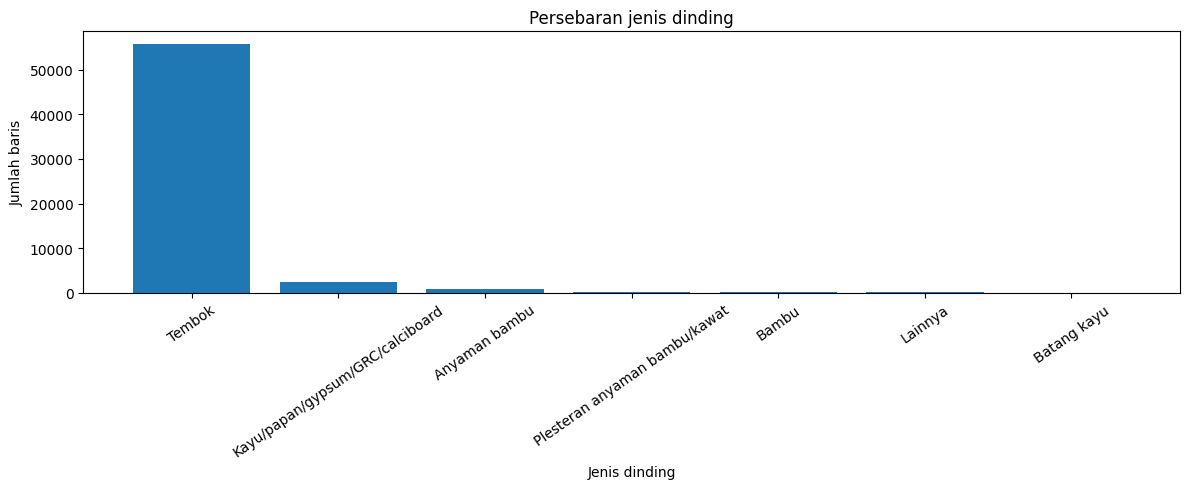

In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
temp = dinding_df.sort_values("jumlah", ascending=False)
ax.bar(temp["kategori"], temp["jumlah"])
ax.set_title("Persebaran jenis dinding")
ax.set_xlabel("Jenis dinding")
ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

### Persebaran jenis atap

In [15]:
atap_df = pd.DataFrame(
    [
        {
            "kode": code,
            "kategori": VALID_ATAP[code],
            "jumlah": counts_valid["id_atap_terluas"].get(code, 0),
        }
        for code in VALID_ATAP
    ]
)
atap_df["persentase_dari_semua_baris"] = atap_df["jumlah"] / total_rows * 100 if total_rows else 0
atap_df["persentase_dari_baris_berimage"] = atap_df["jumlah"] / rows_with_any_image * 100 if rows_with_any_image else 0
atap_df.sort_values("jumlah", ascending=False)

,kode,kategori,jumlah,persentase_dari_semua_baris,persentase_dari_baris_berimage
1,2,Genteng,49527,4.723267,80.417945
3,4,Asbes,5952,0.567627,9.664377
2,3,Seng,2139,0.203991,3.473136
0,1,Beton,1615,0.154019,2.622307
7,8,Lainnya,260,0.024796,0.422167
4,5,Bambu,94,0.008965,0.152630
5,6,Kayu/sirap,20,0.001907,0.032474
6,7,Jerami/ijuk/daun-daunan/rumbia,2,0.000191,0.003247


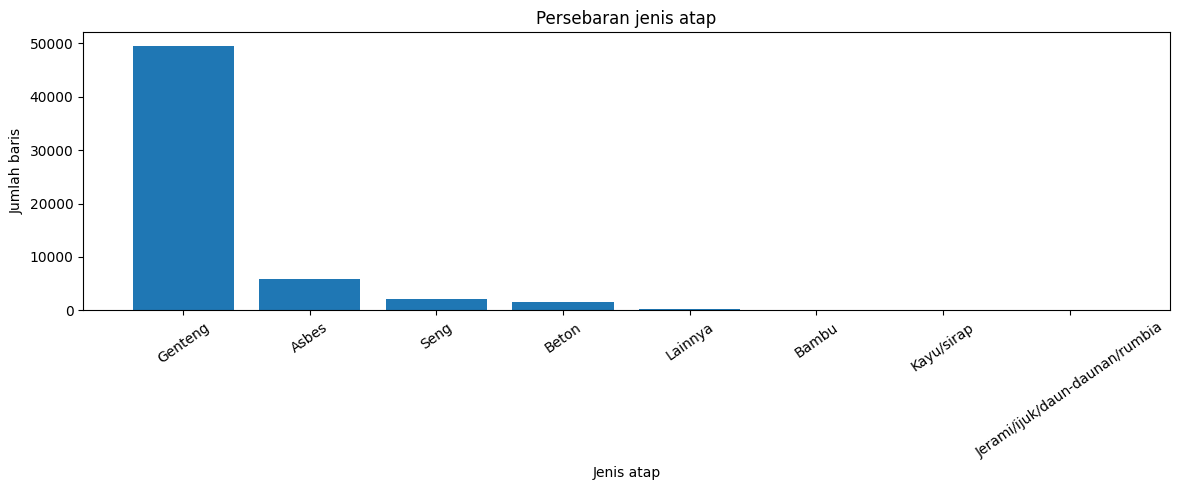

In [16]:
fig, ax = plt.subplots(figsize=(12, 5))
temp = atap_df.sort_values("jumlah", ascending=False)
ax.bar(temp["kategori"], temp["jumlah"])
ax.set_title("Persebaran jenis atap")
ax.set_xlabel("Jenis atap")
ax.set_ylabel("Jumlah baris")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

### Anomali pada tiga fitur kategorikal

In [17]:
anomaly_summary = pd.DataFrame(
    [
        {
            "feature": col,
            "missing": counts_anomaly[col].get("missing", 0),
            "out_of_scope": sum(v for k, v in counts_anomaly[col].items() if k != "missing"),
            "total_anomaly": sum(v for k, v in counts_anomaly[col].items()),
        }
        for col in ["id_lantai_terluas", "id_dinding_terluas", "id_atap_terluas"]
    ]
)

anomaly_summary

,feature,missing,out_of_scope,total_anomaly
0,id_lantai_terluas,0,4366,4366
1,id_dinding_terluas,0,1616,1616
2,id_atap_terluas,0,1978,1978


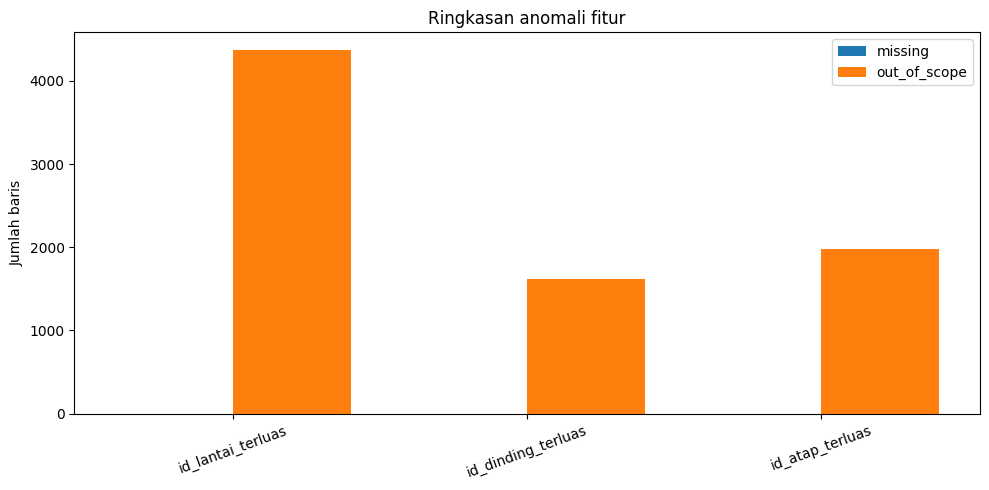

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(anomaly_summary))
ax.bar([i - 0.2 for i in x], anomaly_summary["missing"], width=0.4, label="missing")
ax.bar([i + 0.2 for i in x], anomaly_summary["out_of_scope"], width=0.4, label="out_of_scope")
ax.set_xticks(list(x))
ax.set_xticklabels(anomaly_summary["feature"], rotation=20)
ax.set_title("Ringkasan anomali fitur")
ax.set_ylabel("Jumlah baris")
ax.legend()
plt.tight_layout()
plt.show()

#### Contoh baris anomali

In [19]:
def samples_to_df(samples):
    if not samples:
        return pd.DataFrame()
    return pd.DataFrame(samples)

display(samples_to_df(sample_anomalies["id_lantai_terluas"]))
display(samples_to_df(sample_anomalies["id_dinding_terluas"]))
display(samples_to_df(sample_anomalies["id_atap_terluas"]))

,row_idx,value,reason,schema
0,753,0,out_of_scope,single_image_exterior_only
1,955,0,out_of_scope,multi_images
2,1021,10,out_of_scope,single_image_exterior_only
3,1082,0,out_of_scope,single_image_exterior_only
4,1106,10,out_of_scope,single_image_exterior_only
5,1197,0,out_of_scope,multi_images
6,1286,0,out_of_scope,single_image_exterior_only
7,1776,10,out_of_scope,multi_images
8,2034,10,out_of_scope,single_image_exterior_only
9,2151,0,out_of_scope,single_image_exterior_only


,row_idx,value,reason,schema
0,753,0,out_of_scope,single_image_exterior_only
1,955,0,out_of_scope,multi_images
2,1082,0,out_of_scope,single_image_exterior_only
3,1197,0,out_of_scope,multi_images
4,1286,0,out_of_scope,single_image_exterior_only
5,2151,0,out_of_scope,single_image_exterior_only
6,2395,0,out_of_scope,single_image_exterior_only
7,2554,0,out_of_scope,single_image_exterior_only
8,2573,0,out_of_scope,single_image_exterior_only
9,2759,0,out_of_scope,single_image_exterior_only


,row_idx,value,reason,schema
0,753,0,out_of_scope,single_image_exterior_only
1,955,0,out_of_scope,multi_images
2,1082,0,out_of_scope,single_image_exterior_only
3,1197,0,out_of_scope,multi_images
4,1286,0,out_of_scope,single_image_exterior_only
5,2151,0,out_of_scope,single_image_exterior_only
6,2395,0,out_of_scope,single_image_exterior_only
7,2554,0,out_of_scope,single_image_exterior_only
8,2573,0,out_of_scope,single_image_exterior_only
9,2759,0,out_of_scope,single_image_exterior_only


### Contoh baris yang punya image

In [20]:
pd.DataFrame(sample_image_rows)

,row_idx,id_lantai_terluas,id_dinding_terluas,id_atap_terluas,foto_rumah,foto_rumah_tampak_dalam,image_schema
0,23,6,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/19/10/rumah-79886E42818E41158B323769C4CF81B7.jpg,None,single_image_exterior_only
1,24,4,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/19/14/rumah-7885F7218E1943FD9FD1C17CEDC534E4.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/19/14/rumahdalam-E6EF079CDA6547EE963F4F7D29810EAB.jpg,multi_images
2,79,6,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/13/16/rumah-EE2C8B2CF6564B7EA0349A39FBE14240.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/13/16/rumahdalam-D8905C5149A74C3A8552FAC5044D0E25.jpg,multi_images
3,120,2,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/05/13/10/rumah-80601C2ADD54431AAC53A0546ADD945C.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/05/13/10/rumahdalam-46D12D84CE7A4067B16CCEF9D7E7DE1A.jpg,multi_images
4,135,2,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/17/10/rumah-0403809F8A1D4EBDA04B388936647E88.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/17/10/rumahdalam-CF6167262E5A4DDBB1126525E554A7CF.jpg,multi_images
5,211,2,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/13/16/rumah-9E04E6FBA25E46D5AF3FA049859D7136.jpg,None,single_image_exterior_only
6,231,2,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/11/15/rumah-DFF12E10860344DDB809A0EAFB3F6977.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/11/15/rumahdalam-38CBD0EBE93349A2A3A0FA1D8F82ECE3.jpg,multi_images
7,254,4,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/08/09/rumah-D30537B047C340AFB738424F5E4FC3AE.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/08/09/rumahdalam-EAA6A12E1BB64D3BA6AF4948729B4391.jpg,multi_images
8,281,6,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/19/13/rumah-7CC875F2192C49E1A236D754D55D574B.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=bucket2/monev/dtsen/rumah/2025/04/19/13/rumahdalam-9735493DAB184E82B1DD67C56405297E.jpg,multi_images
9,303,2,1,2,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/13/18/rumah-C63880D48E4C49F090B92800308AA872.jpg,https://minio.jatimprov.go.id/api/v1/buckets/kominfo--dtsen/objects/download?preview=true&prefix=monev/dtsen/rumah/2025/03/13/18/rumahdalam-F6C4913EF96A4F0089E31FFA95EC29BE.jpg,multi_images


## Tabel akhir untuk interpretasi

In [21]:
summary_tables = {
    "image_summary": image_summary,
    "lantai_df": lantai_df.sort_values("jumlah", ascending=False),
    "dinding_df": dinding_df.sort_values("jumlah", ascending=False),
    "atap_df": atap_df.sort_values("jumlah", ascending=False),
    "anomaly_summary": anomaly_summary,
}

for name, df in summary_tables.items():
    print(f"===== {name} =====")
    display(df)

===== image_summary =====


,skema,jumlah,persentase_dari_semua_baris
0,no_images,986988,94.126600
2,multi_images,48000,4.577641
1,single_image_exterior_only,13587,1.295759


===== lantai_df =====


,kode,kategori,jumlah,persentase_dari_semua_baris,persentase_dari_baris_berimage
1,2,Keramik,31575,3.011230,51.268937
5,6,Semen/bata merah,14438,1.376916,23.443259
3,4,Ubin/tegel/teraso,7413,0.706959,12.036631
7,8,Tanah,3087,0.294400,5.012421
0,1,Marmer/granit,338,0.032234,0.548817
2,3,Parket/vinil/karpet,154,0.014687,0.250053
8,9,Lainnya,116,0.011063,0.188351
4,5,Kayu/papan,76,0.007248,0.123403
6,7,Bambu,24,0.002289,0.038969


===== dinding_df =====


,kode,kategori,jumlah,persentase_dari_semua_baris,persentase_dari_baris_berimage
0,1,Tembok,55776,5.319219,90.564567
2,3,Kayu/papan/gypsum/GRC/calciboard,2522,0.240517,4.095020
3,4,Anyaman bambu,906,0.086403,1.471090
1,2,Plesteran anyaman bambu/kawat,297,0.028324,0.482245
5,6,Bambu,243,0.023174,0.394564
6,7,Lainnya,138,0.013161,0.224073
4,5,Batang kayu,89,0.008488,0.144511


===== atap_df =====


,kode,kategori,jumlah,persentase_dari_semua_baris,persentase_dari_baris_berimage
1,2,Genteng,49527,4.723267,80.417945
3,4,Asbes,5952,0.567627,9.664377
2,3,Seng,2139,0.203991,3.473136
0,1,Beton,1615,0.154019,2.622307
7,8,Lainnya,260,0.024796,0.422167
4,5,Bambu,94,0.008965,0.152630
5,6,Kayu/sirap,20,0.001907,0.032474
6,7,Jerami/ijuk/daun-daunan/rumbia,2,0.000191,0.003247


===== anomaly_summary =====


,feature,missing,out_of_scope,total_anomaly
0,id_lantai_terluas,0,4366,4366
1,id_dinding_terluas,0,1616,1616
2,id_atap_terluas,0,1978,1978


### Unique Anomaly Values dan Jumlahnya

In [22]:
# Menampilkan unique anomaly values dan jumlahnya untuk setiap kolom
for col_name in ["id_lantai_terluas", "id_dinding_terluas", "id_atap_terluas"]:
    print(f"\n{'='*60}")
    print(f"ANOMALY - {col_name.upper()}")
    print(f"{'='*60}")
    
    anomaly_data = counts_anomaly[col_name]
    
    if anomaly_data:
        # Ubah ke DataFrame untuk display yang lebih rapi
        anomaly_df = pd.DataFrame([
            {"Anomaly Value": k, "Count": v} 
            for k, v in sorted(anomaly_data.items(), key=lambda x: x[1], reverse=True)
        ])
        print(f"\nTotal unique anomalies: {len(anomaly_df)}")
        print(anomaly_df.to_string(index=False))
    else:
        print("Tidak ada anomali ditemukan")

# Ringkasan total anomali per kolom
print(f"\n{'='*60}")
print("RINGKASAN TOTAL ANOMALI")
print(f"{'='*60}")
summary_anomaly = pd.DataFrame({
    "Column": ["id_lantai_terluas", "id_dinding_terluas", "id_atap_terluas"],
    "Total Anomalies": [
        sum(counts_anomaly["id_lantai_terluas"].values()),
        sum(counts_anomaly["id_dinding_terluas"].values()),
        sum(counts_anomaly["id_atap_terluas"].values())
    ]
})
print(summary_anomaly.to_string(index=False))


ANOMALY - ID_LANTAI_TERLUAS

Total unique anomalies: 2
Anomaly Value  Count
           10   2750
            0   1616

ANOMALY - ID_DINDING_TERLUAS

Total unique anomalies: 1
Anomaly Value  Count
            0   1616

ANOMALY - ID_ATAP_TERLUAS

Total unique anomalies: 2
Anomaly Value  Count
            0   1616
            9    362

RINGKASAN TOTAL ANOMALI
            Column  Total Anomalies
 id_lantai_terluas             4366
id_dinding_terluas             1616
   id_atap_terluas             1978


In [28]:
# Load excel
file_path = "../data/data_keluarga_dinsos_jatim.xlsx"

df = pd.read_excel(file_path, engine="openpyxl")

# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Debug: tampilkan semua nama kolom
print("\n=== DAFTAR KOLOM ===")
for col in df.columns:
    print(repr(col))

# Cari kolom yang mengandung kata terkait
target_columns = []

for col in df.columns:
    col_lower = col.lower()

    if "foto_rumah" in col_lower:
        target_columns.append(col)

    elif "foto_rumah_tampak_dalam" in col_lower:
        target_columns.append(col)

print("\n=== KOLOM YANG DITEMUKAN ===")
print(target_columns)

def extract_urls(cell):
    """
    Support:
    - single URL
    - [url1,url2]
    - [url1, url2]
    - url1,url2
    """

    if pd.isna(cell):
        return []

    cell = str(cell).strip()

    # Cari semua URL
    urls = re.findall(r'https?://[^\s,\]\[]+', cell)

    return urls

# Analisis
for col in target_columns:

    print(f"\n{'='*60}")
    print(f"CHECKING COLUMN: {col}")
    print(f"{'='*60}")

    # Extract URLs
    df[f"{col}_urls"] = df[col].apply(extract_urls)

    # Hitung jumlah URL
    df[f"{col}_url_count"] = df[f"{col}_urls"].apply(len)

    # Statistik
    counts = df[f"{col}_url_count"].value_counts().sort_index()

    print("\nJumlah image per cell:")

    for jumlah, total in counts.items():
        print(f"{jumlah} image(s): {total} rows")

    # Cari row yang punya >1 image
    multi_rows = df[df[f"{col}_url_count"] > 1]

    print(f"\nRows dengan >1 image: {len(multi_rows)}")

    if len(multi_rows) > 0:

        print("\nContoh multi-image rows:")

        print(
            multi_rows[
                [col, f"{col}_url_count"]
            ].head(10).to_string(index=False)
        )


=== DAFTAR KOLOM ===
'kode_provinsi'
'provinsi'
'kode_kabupaten_kota'
'kabupaten_kota'
'kode_kecamatan'
'kecamatan'
'kode_kelurahan_desa'
'kelurahan_desa'
'alamat'
'no_kk'
'nama_kepala_keluarga'
'id_status_keberadaan_keluarga'
'desil_nasional'
'id_dayapenerangan'
'jumlah_anggota_keluarga'
'id_status_penguasaan_bangunan'
'id_lantai_terluas'
'luas_lantai_bangunan'
'id_dinding_terluas'
'id_atap_terluas'
'id_sumber_airminum'
'id_sumberpenerangan'
'id_bb_utama'
'id_fasilitas_bab'
'id_jenis_kloset'
'id_pembuangan_tinja'
'kepemilikan_aset'
'aset_bergerak_tabung_gas'
'aset_bergerak_lemari_es'
'aset_bergerak_ac'
'aset_bergerak_pemanas_air'
'aset_bergerak_telepon_rumah'
'aset_bergerak_tv_datar'
'aset_bergerak_emas_perhiasan'
'aset_bergerak_komputer_laptop_tablet'
'aset_bergerak_sepeda_motor'
'aset_bergerak_sepeda'
'aset_bergerak_mobil'
'aset_bergerak_perahu'
'aset_bergerak_kapal_perahu_motor'
'aset_bergerak_smartphone'
'lahan_tempat_lain'
'rumah_tempat_lain'
'jml_sapi'
'jml_kerbau'
'jml_kuda'
'

## Cek Duplikat Kolom no_kk (Unique Key Check)

In [ ]:
# Load Excel dan cek kolom no_kk
file_path = "../data/data_keluarga_dinsos_jatim.xlsx"
df = pd.read_excel(file_path, engine="openpyxl")

# Bersihkan nama kolom
df.columns = df.columns.str.strip()

# Validasi kolom no_kk ada
if "no_kk" not in df.columns:
    print("❌ Kolom 'no_kk' tidak ditemukan!")
    print("\nKolom yang tersedia:")
    for col in sorted(df.columns):
        print(f"  - {col}")
else:
    print("✅ Kolom 'no_kk' ditemukan\n")
    
    # Statistik dasar
    total_rows = len(df)
    no_kk_series = df["no_kk"]
    
    # Hitung nilai yang tidak null
    non_null_count = no_kk_series.notna().sum()
    null_count = no_kk_series.isna().sum()
    unique_count = no_kk_series.nunique()
    
    print("="*60)
    print("STATISTIK KOLOM no_kk")
    print("="*60)
    print(f"Total baris: {total_rows}")
    print(f"Nilai yang tidak null: {non_null_count}")
    print(f"Nilai yang null/kosong: {null_count}")
    print(f"Nilai unik: {unique_count}")
    print(f"Persentase unik: {unique_count/non_null_count*100:.2f}% (dari non-null values)")
    
    # Status
    if unique_count == non_null_count:
        print("\n✅ SEMUA NILAI UNIQUE (cocok untuk primary key)")
    else:
        print(f"\n❌ ADA {non_null_count - unique_count} DUPLIKAT DITEMUKAN")
    
    print("="*60)

In [ ]:
# Detail duplikat
if "no_kk" in df.columns:
    no_kk_series = df["no_kk"]
    
    # Hitung frekuensi setiap nilai
    value_counts = no_kk_series.value_counts()
    
    # Filter nilai yang muncul lebih dari 1 kali (duplikat)
    duplicates = value_counts[value_counts > 1].sort_values(ascending=False)
    
    if len(duplicates) > 0:
        print("\n" + "="*60)
        print("DETAIL NILAI YANG DUPLIKAT")
        print("="*60)
        print(f"Jumlah nilai yang duplikat: {len(duplicates)}\n")
        
        # Tampilkan dalam DataFrame
        dup_df = pd.DataFrame({
            "no_kk": duplicates.index,
            "Jumlah kemunculan": duplicates.values
        }).reset_index(drop=True)
        
        print(dup_df.to_string(index=False))
        
        print(f"\n\nTotal baris yang duplikat: {duplicates.sum()}")
    else:
        print("\n✅ Tidak ada nilai yang duplikat")

In [ ]:
# Tampilkan contoh baris untuk setiap no_kk yang duplikat
if "no_kk" in df.columns:
    no_kk_series = df["no_kk"]
    value_counts = no_kk_series.value_counts()
    duplicates = value_counts[value_counts > 1]
    
    if len(duplicates) > 0:
        print("\n" + "="*60)
        print("CONTOH BARIS UNTUK SETIAP no_kk YANG DUPLIKAT")
        print("="*60)
        
        for dup_value in duplicates.index[:10]:  # Tampilkan 10 duplikat pertama
            matching_rows = df[df["no_kk"] == dup_value]
            print(f"\nno_kk: {dup_value} ({len(matching_rows)} baris)")
            print("-" * 60)
            
            # Tampilkan beberapa kolom penting
            display_cols = ["no_kk"] + [col for col in df.columns if col not in ["no_kk"] and col != "no_kk"][:5]
            display(matching_rows[display_cols].head())
        
        if len(duplicates) > 10:
            print(f"\n... dan {len(duplicates) - 10} duplikat lainnya")

In [ ]:
# Ringkasan final dan rekomendasi
if "no_kk" in df.columns:
    no_kk_series = df["no_kk"]
    non_null_count = no_kk_series.notna().sum()
    unique_count = no_kk_series.nunique()
    value_counts = no_kk_series.value_counts()
    duplicates = value_counts[value_counts > 1]
    
    print("\n" + "="*60)
    print("RINGKASAN DAN REKOMENDASI")
    print("="*60)
    
    summary_data = {
        "Total Baris": [len(df)],
        "Nilai Non-Null": [non_null_count],
        "Nilai Null": [no_kk_series.isna().sum()],
        "Nilai Unik": [unique_count],
        "Jumlah Duplikat": [len(duplicates)],
        "Total Baris Terduplikasi": [duplicates.sum() if len(duplicates) > 0 else 0],
    }
    
    summary_df = pd.DataFrame(summary_data).T
    summary_df.columns = ["Jumlah"]
    print(summary_df)
    
    print("\n" + "-"*60)
    
    if len(duplicates) == 0 and no_kk_series.isna().sum() == 0:
        print("✅ KESIMPULAN: COCOK DIGUNAKAN SEBAGAI PRIMARY KEY")
        print("   - Semua nilai unik")
        print("   - Tidak ada nilai null/kosong")
    elif len(duplicates) > 0:
        print("❌ KESIMPULAN: TIDAK COCOK SEBAGAI PRIMARY KEY")
        print(f"   - Ada {len(duplicates)} nilai yang muncul lebih dari 1 kali")
        print(f"   - Total {duplicates.sum()} baris terduplikasi")
    else:
        print("⚠️  KESIMPULAN: ADA MASALAH DENGAN DATA")
        print(f"   - Ada {no_kk_series.isna().sum()} nilai null/kosong")
        if len(duplicates) > 0:
            print(f"   - Ada {len(duplicates)} nilai yang duplikat")
    
    print("="*60)